<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/11_Rolling30_DL_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11 — Deep Learning Robustness Models for Rolling-30-Day Historical Variance

This notebook retrains the already-selected deep-learning specifications using the alternative target:

\[
\log(HV^2_{30,t+1}+\epsilon)
\]

where \(HV_{30}\) is the 30-day rolling sample standard deviation of daily log returns.

## Frozen model specifications

The lookbacks are **not re-selected** on this robustness target. They remain the best BTC-validation lookbacks selected in the primary experiment:

- **MLP:** 30 days
- **GRU:** 7 days
- **LSTM:** 14 days

This keeps the robustness exercise focused on whether the model ranking changes when the volatility target changes.

## What this notebook runs

1. BTC-only MLP / GRU / LSTM using the pre-built rolling-30 BTC artifacts.
2. Global pooled MLP / GRU / LSTM across BTC, ETH, SOL and XRP using the same selected lookbacks.
3. Validation comparison against the rolling-30 ARCH-family and baseline results.

The test set remains untouched throughout.

## 1. Imports and reproducibility

In [1]:
from google.colab import drive
from pathlib import Path

import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    GRU,
    LSTM,
    Concatenate,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Paths and fixed experiment configuration

In [2]:
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

ROLLING30_DATA_ROOT = (
    PROJECT_DIR
    / "data"
    / "model_ready"
    / "rolling30_historical_variance"
)

DAILY_FEATURE_PATH = (
    ROLLING30_DATA_ROOT
    / "crypto_daily_features_rolling30_v1.parquet"
)

BTC_ARTIFACT_ROOT = (
    ROLLING30_DATA_ROOT
    / "BTCUSDT"
)

BTC_RESULTS_ROOT = (
    PROJECT_DIR
    / "results"
    / "rolling30_historical_variance"
    / "BTCUSDT"
)

BTC_MODELS_ROOT = (
    PROJECT_DIR
    / "models"
    / "rolling30_historical_variance"
    / "BTCUSDT"
)

GLOBAL_RESULTS_ROOT = (
    PROJECT_DIR
    / "results"
    / "rolling30_historical_variance"
    / "GLOBAL_4_ASSETS"
)

GLOBAL_MODELS_ROOT = (
    PROJECT_DIR
    / "models"
    / "rolling30_historical_variance"
    / "GLOBAL_4_ASSETS"
)

GLOBAL_ARTIFACT_ROOT = (
    ROLLING30_DATA_ROOT
    / "GLOBAL_4_ASSETS"
)

ARCH_RESULTS_PATH = (
    PROJECT_DIR
    / "results"
    / "rolling30_historical_variance"
    / "ARCH"
    / "rolling30_arch_and_baseline_validation_metrics.csv"
)

for directory in [
    BTC_RESULTS_ROOT,
    BTC_MODELS_ROOT,
    GLOBAL_RESULTS_ROOT,
    GLOBAL_MODELS_ROOT,
    GLOBAL_ARTIFACT_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

MODEL_LOOKBACKS = {
    "MLP": 30,
    "GRU": 7,
    "LSTM": 14,
}

LOOKBACK_OPTIONS = sorted(
    set(
        MODEL_LOOKBACKS.values()
    )
)

FEATURE_COLUMNS = [
    "log_rolling_30d_variance",
    "daily_return",
    "absolute_daily_return",
    "high_low_range",
    "log_volume",
    "rolling30_var_mean_7d",
    "rolling30_var_mean_30d",
]

TARGET_COLUMN = (
    "target_log_rolling_30d_variance"
)

ACTUAL_VARIANCE_COLUMN = (
    "target_rolling_30d_variance"
)

VALIDATION_START = pd.Timestamp(
    "2024-08-01",
    tz="UTC",
)

VALIDATION_END = pd.Timestamp(
    "2025-07-31",
    tz="UTC",
)

EPSILON = 1e-12

print("Model lookbacks:", MODEL_LOOKBACKS)
print("Daily feature file:", DAILY_FEATURE_PATH)

Mounted at /content/drive
Model lookbacks: {'MLP': 30, 'GRU': 7, 'LSTM': 14}
Daily feature file: /content/drive/MyDrive/Quant Research/data/model_ready/rolling30_historical_variance/crypto_daily_features_rolling30_v1.parquet


## 3. Common metric helpers

In [3]:
def mae(
    y_true,
    y_pred,
):
    return float(
        np.mean(
            np.abs(
                np.asarray(y_true)
                - np.asarray(y_pred)
            )
        )
    )


def rmse(
    y_true,
    y_pred,
):
    return float(
        np.sqrt(
            np.mean(
                (
                    np.asarray(y_true)
                    - np.asarray(y_pred)
                ) ** 2
            )
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=EPSILON,
):
    y_true = np.maximum(
        np.asarray(
            y_true,
            dtype=float,
        ),
        epsilon,
    )

    y_pred = np.maximum(
        np.asarray(
            y_pred,
            dtype=float,
        ),
        epsilon,
    )

    ratio = (
        y_true
        / y_pred
    )

    return float(
        np.mean(
            ratio
            - np.log(ratio)
            - 1.0
        )
    )


def metric_row(
    asset,
    model,
    y_true,
    y_pred,
    scope,
):
    return {
        "asset":
            asset,

        "model":
            model,

        "scope":
            scope,

        "n_observations":
            int(len(y_true)),

        "mae":
            mae(
                y_true,
                y_pred,
            ),

        "rmse":
            rmse(
                y_true,
                y_pred,
            ),

        "qlike":
            qlike(
                y_true,
                y_pred,
            ),
    }

# Part A — BTC-only selected deep-learning models

The model architectures and training settings are kept consistent with the primary BTC-only notebooks.  
The only material change is the volatility target.

## 4. BTC-only model builders

In [4]:
def compile_btc_model(
    model,
):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],
    )

    return model


def build_btc_mlp(
    lookback_days,
    n_features,
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features,
                )
            ),

            Flatten(),

            Dense(
                64,
                activation="relu",
            ),

            Dropout(0.20),

            Dense(
                32,
                activation="relu",
            ),

            Dropout(0.10),

            Dense(
                1,
                activation="linear",
            ),
        ],
        name="btc_mlp",
    )

    return compile_btc_model(
        model
    )


def build_btc_gru(
    lookback_days,
    n_features,
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features,
                )
            ),

            GRU(
                32,
                dropout=0.0,
                recurrent_dropout=0.0,
            ),

            Dropout(0.20),

            Dense(
                16,
                activation="relu",
            ),

            Dropout(0.10),

            Dense(
                1,
                activation="linear",
            ),
        ],
        name="btc_gru",
    )

    return compile_btc_model(
        model
    )


def build_btc_lstm(
    lookback_days,
    n_features,
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features,
                )
            ),

            LSTM(
                32,
                dropout=0.0,
                recurrent_dropout=0.0,
            ),

            Dropout(0.20),

            Dense(
                16,
                activation="relu",
            ),

            Dropout(0.10),

            Dense(
                1,
                activation="linear",
            ),
        ],
        name="btc_lstm",
    )

    return compile_btc_model(
        model
    )


BTC_MODEL_BUILDERS = {
    "MLP":
        build_btc_mlp,

    "GRU":
        build_btc_gru,

    "LSTM":
        build_btc_lstm,
}

## 5. Load, QC and train the three BTC-only selected specifications

In [5]:
btc_metric_rows = []
btc_prediction_frames = []

for (
    model_name,
    lookback_days,
) in MODEL_LOOKBACKS.items():

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"BTC-only "
        f"{model_name}-{lookback_days}d"
    )

    print(
        "=" * 72
    )

    artifact_dir = (
        BTC_ARTIFACT_ROOT
        / f"lookback_{lookback_days}d"
    )

    config_path = (
        artifact_dir
        / "dataset_configuration.json"
    )

    with open(
        config_path,
        "r",
        encoding="utf-8",
    ) as file:

        config = json.load(
            file
        )

    assert (
        config[
            "candle_interval"
        ]
        == "1d"
    )

    assert (
        config[
            "target"
        ]
        == "log_rolling_30d_variance"
    )

    assert (
        int(
            config[
                "lookback_days"
            ]
        )
        == lookback_days
    )

    assert (
        config[
            "variance_definition"
        ]
        == (
            "square_of_30_day_rolling_std_"
            "of_daily_log_returns"
        )
    )

    X_train = np.load(
        artifact_dir
        / "X_train_scaled.npy"
    )

    X_val = np.load(
        artifact_dir
        / "X_val_scaled.npy"
    )

    y_train = np.load(
        artifact_dir
        / "y_train.npy"
    )

    y_val = np.load(
        artifact_dir
        / "y_val.npy"
    )

    validation_metadata = (
        pd.read_parquet(
            artifact_dir
            / "validation_metadata.parquet"
        )
    )

    validation_metadata[
        "target_date"
    ] = pd.to_datetime(
        validation_metadata[
            "target_date"
        ],
        utc=True,
    )

    assert (
        len(X_train)
        == len(y_train)
    )

    assert (
        len(X_val)
        == len(y_val)
        == len(
            validation_metadata
        )
    )

    assert (
        X_train.shape[1]
        == lookback_days
    )

    assert (
        X_train.shape[2]
        == len(
            FEATURE_COLUMNS
        )
    )

    assert np.isfinite(
        X_train
    ).all()

    assert np.isfinite(
        X_val
    ).all()

    assert np.isfinite(
        y_train
    ).all()

    assert np.isfinite(
        y_val
    ).all()

    assert (
        validation_metadata[
            "target_date"
        ].min()
        == VALIDATION_START
    )

    assert (
        validation_metadata[
            "target_date"
        ].max()
        == VALIDATION_END
    )

    print(
        "Train:",
        X_train.shape
    )

    print(
        "Validation:",
        X_val.shape
    )

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = (
        BTC_MODEL_BUILDERS[
            model_name
        ](
            lookback_days=
                X_train.shape[1],

            n_features=
                X_train.shape[2],
        )
    )

    model_dir = (
        BTC_MODELS_ROOT
        / f"lookback_{lookback_days}d"
        / model_name
    )

    result_dir = (
        BTC_RESULTS_ROOT
        / f"lookback_{lookback_days}d"
        / model_name
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    result_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1,
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),

        ModelCheckpoint(
            filepath=(
                model_dir
                / (
                    f"best_{model_name.lower()}_"
                    f"rolling30.keras"
                )
            ),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val,
        ),
        epochs=200,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks,
        verbose=1,
    )

    pred_log_variance = (
        model.predict(
            X_val,
            batch_size=32,
            verbose=0,
        )
        .reshape(-1)
    )

    pred_variance = np.exp(
        pred_log_variance
    )

    actual_variance = (
        validation_metadata[
            "actual_rolling30_variance"
        ]
        .to_numpy(
            dtype=float
        )
    )

    model_label = (
        f"{model_name}-{lookback_days}d"
    )

    current_metric = metric_row(
        asset="BTCUSDT",
        model=model_label,
        y_true=actual_variance,
        y_pred=pred_variance,
        scope="BTC Standalone DL",
    )

    btc_metric_rows.append(
        current_metric
    )

    prediction_df = (
        validation_metadata.copy()
    )

    prediction_df[
        "model"
    ] = model_label

    prediction_df[
        "pred_log_rolling30_variance"
    ] = pred_log_variance

    prediction_df[
        "pred_rolling30_variance"
    ] = pred_variance

    btc_prediction_frames.append(
        prediction_df
    )

    history_df = pd.DataFrame(
        history.history
    )

    history_df["epoch"] = (
        np.arange(
            len(history_df)
        )
        + 1
    )

    history_df.to_csv(
        result_dir
        / "training_history.csv",
        index=False,
    )

    pd.DataFrame(
        [
            current_metric
        ]
    ).to_csv(
        result_dir
        / "validation_metrics.csv",
        index=False,
    )

    prediction_df.to_parquet(
        result_dir
        / "validation_predictions.parquet",
        index=False,
    )

    model.save(
        model_dir
        / (
            f"final_{model_name.lower()}_"
            "rolling30.keras"
        )
    )

    print(
        f"QLIKE="
        f"{current_metric['qlike']:.6f} | "
        f"MAE="
        f"{current_metric['mae']:.8f} | "
        f"RMSE="
        f"{current_metric['rmse']:.8f}"
    )


btc_metrics_df = (
    pd.DataFrame(
        btc_metric_rows
    )
    .sort_values(
        [
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

btc_predictions_df = pd.concat(
    btc_prediction_frames,
    ignore_index=True,
)

display(
    btc_metrics_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

btc_metrics_df.to_csv(
    BTC_RESULTS_ROOT
    / "btc_selected_dl_validation_metrics.csv",
    index=False,
)


BTC-only MLP-30d
Train: (2452, 30, 7)
Validation: (365, 30, 7)
Epoch 1/200
60/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.0001 - mae: 5.1148
Epoch 1: val_loss improved from None to 6.80234, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/BTCUSDT/lookback_30d/MLP/best_mlp_rolling30.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/BTCUSDT/lookback_30d/MLP/best_mlp_rolling30.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 24.3622 - mae: 4.3577 - val_loss: 6.8023 - val_mae: 2.3995 - learning_rate: 0.0010
Epoch 2/200
69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.5064 - mae: 3.1131
Epoch 2: val_loss improved from 6.80234 to 1.42618, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/BTCUSDT/lookback_30d/MLP/best_mlp_rolling30.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_

,asset,model,scope,n_observations,mae,rmse,qlike
0,BTCUSDT,LSTM-14d,BTC Standalone DL,365,0.00005419,0.00008202,0.007270
1,BTCUSDT,GRU-7d,BTC Standalone DL,365,0.00008093,0.00010742,0.014945
2,BTCUSDT,MLP-30d,BTC Standalone DL,365,0.00019778,0.00031790,0.053709


# Part B — Global four-asset selected deep-learning models

This section preserves the previous global-model design:

- each sequence belongs to one asset;
- feature scalers are fitted separately by asset on training observations only;
- target scalers are fitted separately by asset on training targets only;
- asset identity is supplied as one-hot input;
- validation metrics are reported separately for each asset;
- test sequences are prepared but not evaluated.

## 6. Load and validate rolling-30 all-asset features

In [6]:
if not DAILY_FEATURE_PATH.exists():
    raise FileNotFoundError(
        "Rolling-30 daily feature file "
        "not found:\n"
        f"{DAILY_FEATURE_PATH}"
    )

daily_df = pd.read_parquet(
    DAILY_FEATURE_PATH
)

daily_df["date"] = pd.to_datetime(
    daily_df["date"],
    utc=True,
)

daily_df["target_date"] = pd.to_datetime(
    daily_df["target_date"],
    utc=True,
    errors="coerce",
)

daily_df = (
    daily_df
    .loc[
        daily_df[
            "symbol"
        ].isin(
            ASSETS
        )
    ]
    .sort_values(
        [
            "symbol",
            "date",
        ]
    )
    .reset_index(drop=True)
)

required_columns = {
    "symbol",
    "date",
    "target_date",
    TARGET_COLUMN,
    ACTUAL_VARIANCE_COLUMN,
    "split",
    *FEATURE_COLUMNS,
}

missing_columns = (
    required_columns
    - set(
        daily_df.columns
    )
)

if missing_columns:
    raise ValueError(
        "Missing columns: "
        f"{missing_columns}"
    )

if daily_df.duplicated(
    subset=[
        "symbol",
        "date",
    ]
).any():
    raise ValueError(
        "Duplicate symbol-date rows found."
    )

display(
    daily_df
    .groupby("symbol")
    .agg(
        first_date=(
            "date",
            "min",
        ),
        last_date=(
            "date",
            "max",
        ),
        rows=(
            "date",
            "size",
        ),
        valid_targets=(
            TARGET_COLUMN,
            "count",
        ),
    )
)

,first_date,last_date,rows,valid_targets
symbol,,,,
BTCUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3242
ETHUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3242
SOLUSDT,2020-08-11 00:00:00+00:00,2026-08-01 00:00:00+00:00,2182,2152
XRPUSDT,2018-05-04 00:00:00+00:00,2026-08-01 00:00:00+00:00,3012,2982


## 7. Create asset-specific sequences for the selected lookbacks

In [7]:
def create_asset_sequences(
    asset_df,
    feature_columns,
    lookback_days,
):
    asset_df = (
        asset_df
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    X_values = []
    y_values = []
    metadata_rows = []

    for end_index in range(
        lookback_days - 1,
        len(asset_df),
    ):

        start_index = (
            end_index
            - lookback_days
            + 1
        )

        window = asset_df.iloc[
            start_index:
            end_index + 1
        ]

        final_row = (
            asset_df.iloc[
                end_index
            ]
        )

        dates = window[
            "date"
        ]

        if (
            dates.iloc[-1]
            - dates.iloc[0]
            != pd.Timedelta(
                days=lookback_days - 1
            )
        ):
            continue

        if not (
            dates.diff()
            .dropna()
            .eq(
                pd.Timedelta(days=1)
            )
            .all()
        ):
            continue

        if (
            window[
                feature_columns
            ]
            .isna()
            .any()
            .any()
        ):
            continue

        if pd.isna(
            final_row[
                TARGET_COLUMN
            ]
        ):
            continue

        if (
            final_row[
                "target_date"
            ]
            - final_row[
                "date"
            ]
            != pd.Timedelta(days=1)
        ):
            continue

        if (
            final_row[
                "split"
            ]
            not in {
                "train",
                "validation",
                "test",
            }
        ):
            continue

        X_values.append(
            window[
                feature_columns
            ]
            .to_numpy(
                dtype=np.float32
            )
        )

        y_values.append(
            np.float32(
                final_row[
                    TARGET_COLUMN
                ]
            )
        )

        metadata_rows.append({
            "symbol":
                final_row[
                    "symbol"
                ],

            "sequence_start_date":
                dates.iloc[0],

            "sequence_end_date":
                final_row[
                    "date"
                ],

            "target_date":
                final_row[
                    "target_date"
                ],

            "actual_log_rolling30_variance":
                final_row[
                    TARGET_COLUMN
                ],

            "actual_rolling30_variance":
                final_row[
                    ACTUAL_VARIANCE_COLUMN
                ],

            "split":
                final_row[
                    "split"
                ],
        })

    return (
        np.asarray(
            X_values,
            dtype=np.float32,
        ),

        np.asarray(
            y_values,
            dtype=np.float32,
        ),

        pd.DataFrame(
            metadata_rows
        ),
    )


datasets_by_lookback = {}

for lookback_days in (
    LOOKBACK_OPTIONS
):

    print(
        "\n"
        + "=" * 60
    )

    print(
        f"LOOKBACK = "
        f"{lookback_days} DAYS"
    )

    print(
        "=" * 60
    )

    asset_datasets = {}

    for symbol in ASSETS:

        (
            X_asset,
            y_asset,
            meta_asset,
        ) = create_asset_sequences(
            daily_df.loc[
                daily_df[
                    "symbol"
                ].eq(symbol)
            ].copy(),

            FEATURE_COLUMNS,
            lookback_days,
        )

        if meta_asset.empty:
            raise ValueError(
                f"No valid sequences "
                f"for {symbol}, "
                f"lookback="
                f"{lookback_days}"
            )

        validation_meta = (
            meta_asset.loc[
                meta_asset[
                    "split"
                ].eq(
                    "validation"
                )
            ]
        )

        assert (
            validation_meta[
                "target_date"
            ].min()
            == VALIDATION_START
        )

        assert (
            validation_meta[
                "target_date"
            ].max()
            == VALIDATION_END
        )

        assert (
            len(
                validation_meta
            )
            == 365
        )

        asset_datasets[
            symbol
        ] = {
            "X_raw":
                X_asset,

            "y_raw":
                y_asset,

            "metadata":
                meta_asset,
        }

        print(
            symbol,
            X_asset.shape,
            meta_asset[
                "split"
            ]
            .value_counts()
            .to_dict(),
        )

    datasets_by_lookback[
        lookback_days
    ] = asset_datasets


LOOKBACK = 7 DAYS
BTCUSDT (3205, 7, 7) {'train': 2475, 'validation': 365, 'test': 365}
ETHUSDT (3205, 7, 7) {'train': 2475, 'validation': 365, 'test': 365}
SOLUSDT (2115, 7, 7) {'train': 1385, 'validation': 365, 'test': 365}
XRPUSDT (2945, 7, 7) {'train': 2215, 'validation': 365, 'test': 365}

LOOKBACK = 14 DAYS
BTCUSDT (3198, 14, 7) {'train': 2468, 'validation': 365, 'test': 365}
ETHUSDT (3198, 14, 7) {'train': 2468, 'validation': 365, 'test': 365}
SOLUSDT (2108, 14, 7) {'train': 1378, 'validation': 365, 'test': 365}
XRPUSDT (2938, 14, 7) {'train': 2208, 'validation': 365, 'test': 365}

LOOKBACK = 30 DAYS
BTCUSDT (3182, 30, 7) {'train': 2452, 'validation': 365, 'test': 365}
ETHUSDT (3182, 30, 7) {'train': 2452, 'validation': 365, 'test': 365}
SOLUSDT (2092, 30, 7) {'train': 1362, 'validation': 365, 'test': 365}
XRPUSDT (2922, 30, 7) {'train': 2192, 'validation': 365, 'test': 365}


## 8. Per-asset scaling and pooled arrays

In [8]:
def build_pooled_dataset(
    asset_datasets,
):
    asset_to_index = {
        symbol: index
        for index, symbol
        in enumerate(ASSETS)
    }

    feature_scalers = {}
    target_scalers = {}

    pooled = {
        split: {
            "X": [],
            "A": [],
            "y_scaled": [],
            "metadata": [],
        }
        for split in [
            "train",
            "validation",
            "test",
        ]
    }

    for symbol in ASSETS:

        dataset = (
            asset_datasets[
                symbol
            ]
        )

        X_raw = (
            dataset[
                "X_raw"
            ]
        )

        y_raw = (
            dataset[
                "y_raw"
            ]
        )

        metadata = (
            dataset[
                "metadata"
            ]
        )

        train_mask = (
            metadata[
                "split"
            ]
            .eq("train")
            .to_numpy()
        )

        if (
            train_mask.sum()
            == 0
        ):
            raise ValueError(
                f"No training data "
                f"for {symbol}."
            )

        n_features = (
            X_raw.shape[2]
        )

        feature_scaler = (
            StandardScaler()
            .fit(
                X_raw[
                    train_mask
                ]
                .reshape(
                    -1,
                    n_features,
                )
            )
        )

        target_scaler = (
            StandardScaler()
            .fit(
                y_raw[
                    train_mask
                ]
                .reshape(
                    -1,
                    1,
                )
            )
        )

        feature_scalers[
            symbol
        ] = feature_scaler

        target_scalers[
            symbol
        ] = target_scaler

        X_scaled = (
            feature_scaler
            .transform(
                X_raw.reshape(
                    -1,
                    n_features,
                )
            )
            .reshape(
                X_raw.shape
            )
            .astype(
                np.float32
            )
        )

        y_scaled = (
            target_scaler
            .transform(
                y_raw.reshape(
                    -1,
                    1,
                )
            )
            .reshape(-1)
            .astype(
                np.float32
            )
        )

        asset_one_hot = (
            np.zeros(
                (
                    len(metadata),
                    len(ASSETS),
                ),
                dtype=np.float32,
            )
        )

        asset_one_hot[
            :,
            asset_to_index[
                symbol
            ],
        ] = 1.0

        for split in pooled:

            mask = (
                metadata[
                    "split"
                ]
                .eq(split)
                .to_numpy()
            )

            pooled[
                split
            ]["X"].append(
                X_scaled[
                    mask
                ]
            )

            pooled[
                split
            ]["A"].append(
                asset_one_hot[
                    mask
                ]
            )

            pooled[
                split
            ]["y_scaled"].append(
                y_scaled[
                    mask
                ]
            )

            pooled[
                split
            ]["metadata"].append(
                metadata.loc[
                    mask
                ].copy()
            )

    for split in pooled:

        pooled[
            split
        ]["X"] = np.concatenate(
            pooled[
                split
            ]["X"]
        )

        pooled[
            split
        ]["A"] = np.concatenate(
            pooled[
                split
            ]["A"]
        )

        pooled[
            split
        ]["y_scaled"] = np.concatenate(
            pooled[
                split
            ]["y_scaled"]
        )

        pooled[
            split
        ]["metadata"] = pd.concat(
            pooled[
                split
            ]["metadata"],
            ignore_index=True,
        )

    return {
        "pooled":
            pooled,

        "feature_scalers":
            feature_scalers,

        "target_scalers":
            target_scalers,
    }


pooled_by_lookback = {}

for lookback_days in (
    LOOKBACK_OPTIONS
):

    current = build_pooled_dataset(
        datasets_by_lookback[
            lookback_days
        ]
    )

    pooled_by_lookback[
        lookback_days
    ] = current

    pooled = (
        current[
            "pooled"
        ]
    )

    print(
        f"\nLookback "
        f"{lookback_days}d"
    )

    print(
        "Train:",
        pooled[
            "train"
        ]["X"].shape,
    )

    print(
        "Validation:",
        pooled[
            "validation"
        ]["X"].shape,
    )

    print(
        "Test prepared:",
        pooled[
            "test"
        ]["X"].shape,
    )

    display(
        pooled[
            "validation"
        ]["metadata"][
            "symbol"
        ]
        .value_counts()
    )


Lookback 7d
Train: (8550, 7, 7)
Validation: (1460, 7, 7)
Test prepared: (1460, 7, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365



Lookback 14d
Train: (8522, 14, 7)
Validation: (1460, 14, 7)
Test prepared: (1460, 14, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365



Lookback 30d
Train: (8458, 30, 7)
Validation: (1460, 30, 7)
Test prepared: (1460, 30, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365


## 9. Save global pooled artifacts and scalers

In [9]:
for lookback_days in (
    LOOKBACK_OPTIONS
):

    current = (
        pooled_by_lookback[
            lookback_days
        ]
    )

    pooled = (
        current[
            "pooled"
        ]
    )

    artifact_dir = (
        GLOBAL_ARTIFACT_ROOT
        / (
            f"lookback_"
            f"{lookback_days}d"
        )
    )

    artifact_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    arrays_to_save = {
        "X_train_scaled.npy":
            pooled[
                "train"
            ]["X"],

        "X_val_scaled.npy":
            pooled[
                "validation"
            ]["X"],

        "X_test_scaled.npy":
            pooled[
                "test"
            ]["X"],

        "asset_train_one_hot.npy":
            pooled[
                "train"
            ]["A"],

        "asset_val_one_hot.npy":
            pooled[
                "validation"
            ]["A"],

        "asset_test_one_hot.npy":
            pooled[
                "test"
            ]["A"],

        "y_train_scaled.npy":
            pooled[
                "train"
            ]["y_scaled"],

        "y_val_scaled.npy":
            pooled[
                "validation"
            ]["y_scaled"],

        "y_test_scaled.npy":
            pooled[
                "test"
            ]["y_scaled"],
    }

    for (
        filename,
        array,
    ) in arrays_to_save.items():

        np.save(
            artifact_dir
            / filename,
            array,
        )

    pooled[
        "validation"
    ]["metadata"].to_parquet(
        artifact_dir
        / "validation_metadata.parquet",
        index=False,
    )

    pooled[
        "test"
    ]["metadata"].to_parquet(
        artifact_dir
        / "test_metadata.parquet",
        index=False,
    )

    joblib.dump(
        current[
            "feature_scalers"
        ],
        artifact_dir
        / "feature_scalers_by_asset.joblib",
    )

    joblib.dump(
        current[
            "target_scalers"
        ],
        artifact_dir
        / "target_scalers_by_asset.joblib",
    )

    configuration = {
        "assets":
            ASSETS,

        "lookback_days":
            lookback_days,

        "feature_columns":
            FEATURE_COLUMNS,

        "target":
            TARGET_COLUMN,

        "volatility_definition":
            (
                "30_day_rolling_std_"
                "of_daily_log_returns"
            ),

        "variance_definition":
            (
                "square_of_30_day_rolling_std_"
                "of_daily_log_returns"
            ),

        "train_shape":
            list(
                pooled[
                    "train"
                ]["X"].shape
            ),

        "validation_shape":
            list(
                pooled[
                    "validation"
                ]["X"].shape
            ),

        "test_shape":
            list(
                pooled[
                    "test"
                ]["X"].shape
            ),
    }

    with open(
        artifact_dir
        / "experiment_configuration.json",
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            configuration,
            file,
            indent=2,
        )

    print(
        "Saved global artifacts:",
        artifact_dir,
    )

Saved global artifacts: /content/drive/MyDrive/Quant Research/data/model_ready/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_7d
Saved global artifacts: /content/drive/MyDrive/Quant Research/data/model_ready/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_14d
Saved global artifacts: /content/drive/MyDrive/Quant Research/data/model_ready/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_30d


## 10. Global metric inverse-transform helpers

In [10]:
def inverse_target_predictions(
    pred_scaled,
    metadata,
    target_scalers,
):
    pred_log = np.empty(
        len(pred_scaled),
        dtype=float,
    )

    for symbol in ASSETS:

        mask = (
            metadata[
                "symbol"
            ]
            .eq(symbol)
            .to_numpy()
        )

        pred_log[
            mask
        ] = (
            target_scalers[
                symbol
            ]
            .inverse_transform(
                pred_scaled[
                    mask
                ]
                .reshape(
                    -1,
                    1,
                )
            )
            .reshape(-1)
        )

    return (
        pred_log,
        np.exp(
            pred_log
        ),
    )


def evaluate_by_asset(
    model_name,
    pred_variance,
    metadata,
):
    rows = []

    for symbol in ASSETS:

        mask = (
            metadata[
                "symbol"
            ]
            .eq(symbol)
            .to_numpy()
        )

        y_true = (
            metadata.loc[
                mask,
                "actual_rolling30_variance",
            ]
            .to_numpy(
                dtype=float
            )
        )

        y_pred = (
            pred_variance[
                mask
            ]
        )

        rows.append(
            metric_row(
                asset=symbol,
                model=model_name,
                y_true=y_true,
                y_pred=y_pred,
                scope="Global DL",
            )
        )

    return pd.DataFrame(
        rows
    )

## 11. Global model builders — unchanged from the selected-lookback notebook

In [11]:
def compile_global_model(
    sequence_input,
    asset_input,
    x,
    name,
):
    x = Concatenate()(
        [
            x,
            asset_input,
        ]
    )

    x = Dense(
        16,
        activation="relu",
    )(
        x
    )

    output = Dense(
        1
    )(
        x
    )

    model = Model(
        inputs=[
            sequence_input,
            asset_input,
        ],
        outputs=output,
        name=name,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],
    )

    return model


def build_global_mlp(
    lookback_days,
    n_features,
    n_assets,
):
    sequence_input = Input(
        shape=(
            lookback_days,
            n_features,
        ),
        name="sequence_input",
    )

    asset_input = Input(
        shape=(
            n_assets,
        ),
        name="asset_input",
    )

    x = Flatten()(
        sequence_input
    )

    x = Dense(
        64,
        activation="relu",
    )(
        x
    )

    x = Dropout(
        0.20
    )(
        x
    )

    x = Dense(
        32,
        activation="relu",
    )(
        x
    )

    return compile_global_model(
        sequence_input,
        asset_input,
        x,
        "global_mlp",
    )


def build_global_gru(
    lookback_days,
    n_features,
    n_assets,
):
    sequence_input = Input(
        shape=(
            lookback_days,
            n_features,
        ),
        name="sequence_input",
    )

    asset_input = Input(
        shape=(
            n_assets,
        ),
        name="asset_input",
    )

    x = GRU(
        32,
        dropout=0.0,
        recurrent_dropout=0.0,
    )(
        sequence_input
    )

    x = Dropout(
        0.20
    )(
        x
    )

    x = Dense(
        16,
        activation="relu",
    )(
        x
    )

    return compile_global_model(
        sequence_input,
        asset_input,
        x,
        "global_gru",
    )


def build_global_lstm(
    lookback_days,
    n_features,
    n_assets,
):
    sequence_input = Input(
        shape=(
            lookback_days,
            n_features,
        ),
        name="sequence_input",
    )

    asset_input = Input(
        shape=(
            n_assets,
        ),
        name="asset_input",
    )

    x = LSTM(
        32,
        dropout=0.0,
        recurrent_dropout=0.0,
    )(
        sequence_input
    )

    x = Dropout(
        0.20
    )(
        x
    )

    x = Dense(
        16,
        activation="relu",
    )(
        x
    )

    return compile_global_model(
        sequence_input,
        asset_input,
        x,
        "global_lstm",
    )


GLOBAL_MODEL_BUILDERS = {
    "MLP":
        build_global_mlp,

    "GRU":
        build_global_gru,

    "LSTM":
        build_global_lstm,
}

## 12. Train Global MLP-30d, GRU-7d and LSTM-14d

In [12]:
global_metric_frames = []
global_prediction_frames = []

for (
    model_name,
    builder,
) in GLOBAL_MODEL_BUILDERS.items():

    lookback_days = (
        MODEL_LOOKBACKS[
            model_name
        ]
    )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Global "
        f"{model_name}-"
        f"{lookback_days}d"
    )

    print(
        "=" * 72
    )

    current = (
        pooled_by_lookback[
            lookback_days
        ]
    )

    pooled = (
        current[
            "pooled"
        ]
    )

    target_scalers = (
        current[
            "target_scalers"
        ]
    )

    X_train = (
        pooled[
            "train"
        ]["X"]
    )

    A_train = (
        pooled[
            "train"
        ]["A"]
    )

    y_train_scaled = (
        pooled[
            "train"
        ]["y_scaled"]
    )

    X_val = (
        pooled[
            "validation"
        ]["X"]
    )

    A_val = (
        pooled[
            "validation"
        ]["A"]
    )

    y_val_scaled = (
        pooled[
            "validation"
        ]["y_scaled"]
    )

    validation_metadata = (
        pooled[
            "validation"
        ]["metadata"]
        .reset_index(drop=True)
    )

    assert (
        len(
            validation_metadata
        )
        == (
            365
            * len(ASSETS)
        )
    )

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = builder(
        lookback_days=
            X_train.shape[1],

        n_features=
            X_train.shape[2],

        n_assets=
            A_train.shape[1],
    )

    model_dir = (
        GLOBAL_MODELS_ROOT
        / f"lookback_{lookback_days}d"
        / model_name
    )

    result_dir = (
        GLOBAL_RESULTS_ROOT
        / f"lookback_{lookback_days}d"
        / model_name
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    result_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1,
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),

        ModelCheckpoint(
            filepath=(
                model_dir
                / (
                    "best_global_"
                    f"{model_name.lower()}_"
                    "rolling30.keras"
                )
            ),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        [
            X_train,
            A_train,
        ],
        y_train_scaled,
        validation_data=(
            [
                X_val,
                A_val,
            ],
            y_val_scaled,
        ),
        epochs=200,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks,
        verbose=1,
    )

    pred_scaled = (
        model.predict(
            [
                X_val,
                A_val,
            ],
            batch_size=32,
            verbose=0,
        )
        .reshape(-1)
    )

    (
        pred_log_variance,
        pred_variance,
    ) = inverse_target_predictions(
        pred_scaled,
        validation_metadata,
        target_scalers,
    )

    global_model_label = (
        f"Global-"
        f"{model_name}-"
        f"{lookback_days}d"
    )

    metrics_df = (
        evaluate_by_asset(
            model_name=
                global_model_label,

            pred_variance=
                pred_variance,

            metadata=
                validation_metadata,
        )
    )

    global_metric_frames.append(
        metrics_df
    )

    prediction_df = (
        validation_metadata.copy()
    )

    prediction_df[
        "model"
    ] = (
        global_model_label
    )

    prediction_df[
        "pred_log_rolling30_variance"
    ] = (
        pred_log_variance
    )

    prediction_df[
        "pred_rolling30_variance"
    ] = (
        pred_variance
    )

    global_prediction_frames.append(
        prediction_df
    )

    history_df = pd.DataFrame(
        history.history
    )

    history_df["epoch"] = (
        np.arange(
            len(history_df)
        )
        + 1
    )

    history_df.to_csv(
        result_dir
        / "training_history.csv",
        index=False,
    )

    metrics_df.to_csv(
        result_dir
        / "validation_metrics_by_asset.csv",
        index=False,
    )

    prediction_df.to_parquet(
        result_dir
        / "validation_predictions.parquet",
        index=False,
    )

    model.save(
        model_dir
        / (
            "final_global_"
            f"{model_name.lower()}_"
            "rolling30.keras"
        )
    )

    display(
        metrics_df
        .sort_values(
            "qlike"
        )
        .style.format({
            "mae":
                "{:.8f}",
            "rmse":
                "{:.8f}",
            "qlike":
                "{:.6f}",
        })
    )


global_dl_metrics_df = (
    pd.concat(
        global_metric_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

global_dl_predictions_df = (
    pd.concat(
        global_prediction_frames,
        ignore_index=True,
    )
)


global_dl_metrics_df.to_csv(
    GLOBAL_RESULTS_ROOT
    / "rolling30_global_dl_validation_metrics.csv",
    index=False,
)

global_dl_predictions_df.to_parquet(
    GLOBAL_RESULTS_ROOT
    / "rolling30_global_dl_validation_predictions.parquet",
    index=False,
)


Global MLP-30d
Epoch 1/200
253/265 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4860 - mae: 0.4970
Epoch 1: val_loss improved from None to 0.09297, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp_rolling30.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp_rolling30.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2692 - mae: 0.3710 - val_loss: 0.0930 - val_mae: 0.2403 - learning_rate: 0.0010
Epoch 2/200
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1350 - mae: 0.2757
Epoch 2: val_loss improved from 0.09297 to 0.08329, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp_rolling30.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_

,asset,model,scope,n_observations,mae,rmse,qlike
0,BTCUSDT,Global-MLP-30d,Global DL,365,0.00004444,0.00006782,0.005388
2,SOLUSDT,Global-MLP-30d,Global DL,365,0.00017053,0.00027837,0.006981
1,ETHUSDT,Global-MLP-30d,Global DL,365,0.00013476,0.00019107,0.008155
3,XRPUSDT,Global-MLP-30d,Global DL,365,0.00031676,0.00059157,0.012235



Global GRU-7d
Epoch 1/200
261/268 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4914 - mae: 0.5065
Epoch 1: val_loss improved from None to 0.06889, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru_rolling30.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru_rolling30.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.2783 - mae: 0.3750 - val_loss: 0.0689 - val_mae: 0.1998 - learning_rate: 0.0010
Epoch 2/200
259/268 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0989 - mae: 0.2274
Epoch 2: val_loss improved from 0.06889 to 0.06223, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru_rolling30.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_vari

,asset,model,scope,n_observations,mae,rmse,qlike
0,BTCUSDT,Global-GRU-7d,Global DL,365,0.00003686,0.00006310,0.004830
2,SOLUSDT,Global-GRU-7d,Global DL,365,0.00012574,0.00022748,0.005077
1,ETHUSDT,Global-GRU-7d,Global DL,365,0.00008526,0.00016015,0.005485
3,XRPUSDT,Global-GRU-7d,Global DL,365,0.00022270,0.00041539,0.010544



Global LSTM-14d
Epoch 1/200
264/267 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5273 - mae: 0.5086
Epoch 1: val_loss improved from None to 0.11041, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_14d/LSTM/best_global_lstm_rolling30.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_14d/LSTM/best_global_lstm_rolling30.keras
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3002 - mae: 0.3786 - val_loss: 0.1104 - val_mae: 0.2632 - learning_rate: 0.0010
Epoch 2/200
264/267 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1342 - mae: 0.2599
Epoch 2: val_loss improved from 0.11041 to 0.07942, saving model to /content/drive/MyDrive/Quant Research/models/rolling30_historical_variance/GLOBAL_4_ASSETS/lookback_14d/LSTM/best_global_lstm_rolling30.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/rolling30_hist

,asset,model,scope,n_observations,mae,rmse,qlike
0,BTCUSDT,Global-LSTM-14d,Global DL,365,0.00003891,0.00006433,0.005068
2,SOLUSDT,Global-LSTM-14d,Global DL,365,0.00013086,0.00022477,0.005336
1,ETHUSDT,Global-LSTM-14d,Global DL,365,0.00008663,0.00016722,0.005766
3,XRPUSDT,Global-LSTM-14d,Global DL,365,0.00023897,0.00043665,0.010786


## 13. Compare global DL against ARCH-family and rolling-30 baselines

This is the primary cross-asset robustness comparison.

In [13]:
if not ARCH_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "ARCH robustness result file "
        "not found:\n"
        f"{ARCH_RESULTS_PATH}"
    )

arch_baseline_df = pd.read_csv(
    ARCH_RESULTS_PATH
)

required_metric_columns = {
    "asset",
    "model",
    "n_observations",
    "mae",
    "rmse",
    "qlike",
}

missing_arch_columns = (
    required_metric_columns
    - set(
        arch_baseline_df.columns
    )
)

if missing_arch_columns:
    raise ValueError(
        "ARCH/baseline metrics are "
        "missing columns: "
        f"{missing_arch_columns}"
    )

arch_baseline_core_df = (
    arch_baseline_df[
        [
            "asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .copy()
)

arch_baseline_core_df[
    "scope"
] = np.where(
    arch_baseline_core_df[
        "model"
    ].str.contains(
        "GARCH",
        case=False,
        regex=False,
    ),
    "ARCH",
    "Baseline",
)

global_core_df = (
    global_dl_metrics_df[
        [
            "asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
            "scope",
        ]
    ]
    .copy()
)

final_cross_asset_df = (
    pd.concat(
        [
            arch_baseline_core_df,
            global_core_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

final_cross_asset_df[
    "qlike_rank_within_asset"
] = (
    final_cross_asset_df
    .groupby("asset")[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

final_cross_asset_df = (
    final_cross_asset_df[
        [
            "asset",
            "qlike_rank_within_asset",
            "model",
            "scope",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
)

comparison_path = (
    GLOBAL_RESULTS_ROOT
    / (
        "rolling30_final_validation_"
        "comparison_by_asset.csv"
    )
)

final_cross_asset_df.to_csv(
    comparison_path,
    index=False,
)

display(
    final_cross_asset_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

print(
    "Saved:",
    comparison_path,
)

,asset,qlike_rank_within_asset,model,scope,n_observations,mae,rmse,qlike
0,BTCUSDT,1,"GARCH(1,1)",ARCH,365,0.00002768,0.00004514,0.002567
1,BTCUSDT,2,"GJR-GARCH(1,1)",ARCH,365,0.00002768,0.00004526,0.002584
2,BTCUSDT,3,"EGARCH(1,1)",ARCH,365,0.00003273,0.00004778,0.002765
3,BTCUSDT,4,Global-GRU-7d,Global DL,365,0.00003686,0.00006310,0.004830
4,BTCUSDT,5,Rolling30 Persistence,Baseline,365,0.00003273,0.00006389,0.004915
5,BTCUSDT,6,Global-LSTM-14d,Global DL,365,0.00003891,0.00006433,0.005068
6,BTCUSDT,7,Global-MLP-30d,Global DL,365,0.00004444,0.00006782,0.005388
7,BTCUSDT,8,7-Day Mean Rolling30 Variance,Baseline,365,0.00007671,0.00012011,0.015032
8,BTCUSDT,9,30-Day Mean Rolling30 Variance,Baseline,365,0.00019887,0.00026192,0.066439
9,ETHUSDT,1,"GARCH(1,1)",ARCH,365,0.00006762,0.00011763,0.003161


Saved: /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/GLOBAL_4_ASSETS/rolling30_final_validation_comparison_by_asset.csv


## 14. Best validation model by asset

In [14]:
best_model_by_asset_df = (
    final_cross_asset_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False,
    )
    .first()
)

best_model_by_asset_df.to_csv(
    GLOBAL_RESULTS_ROOT
    / (
        "rolling30_best_validation_"
        "model_by_asset.csv"
    ),
    index=False,
)

display(
    best_model_by_asset_df[
        [
            "asset",
            "model",
            "scope",
            "mae",
            "rmse",
            "qlike",
        ]
    ].style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

,asset,model,scope,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",ARCH,0.00002768,0.00004514,0.002567
1,ETHUSDT,"GARCH(1,1)",ARCH,0.00006762,0.00011763,0.003161
2,SOLUSDT,"GARCH(1,1)",ARCH,0.00008906,0.00016248,0.002666
3,XRPUSDT,"EGARCH(1,1)",ARCH,0.00011230,0.00023702,0.004998


## 15. BTC robustness appendix — standalone vs global vs ARCH/baselines

In [15]:
btc_all_models_df = (
    pd.concat(
        [
            final_cross_asset_df.loc[
                final_cross_asset_df[
                    "asset"
                ].eq("BTCUSDT")
            ][
                [
                    "asset",
                    "model",
                    "scope",
                    "n_observations",
                    "mae",
                    "rmse",
                    "qlike",
                ]
            ],

            btc_metrics_df[
                [
                    "asset",
                    "model",
                    "scope",
                    "n_observations",
                    "mae",
                    "rmse",
                    "qlike",
                ]
            ],
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

btc_all_models_df[
    "qlike_rank"
] = (
    np.arange(
        len(
            btc_all_models_df
        )
    )
    + 1
)

btc_all_models_df.to_csv(
    BTC_RESULTS_ROOT
    / (
        "rolling30_btc_all_models_"
        "validation_comparison.csv"
    ),
    index=False,
)

display(
    btc_all_models_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

,asset,model,scope,n_observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,"GARCH(1,1)",ARCH,365,0.00002768,0.00004514,0.002567,1
1,BTCUSDT,"GJR-GARCH(1,1)",ARCH,365,0.00002768,0.00004526,0.002584,2
2,BTCUSDT,"EGARCH(1,1)",ARCH,365,0.00003273,0.00004778,0.002765,3
3,BTCUSDT,Global-GRU-7d,Global DL,365,0.00003686,0.00006310,0.004830,4
4,BTCUSDT,Rolling30 Persistence,Baseline,365,0.00003273,0.00006389,0.004915,5
5,BTCUSDT,Global-LSTM-14d,Global DL,365,0.00003891,0.00006433,0.005068,6
6,BTCUSDT,Global-MLP-30d,Global DL,365,0.00004444,0.00006782,0.005388,7
7,BTCUSDT,LSTM-14d,BTC Standalone DL,365,0.00005419,0.00008202,0.007270,8
8,BTCUSDT,GRU-7d,BTC Standalone DL,365,0.00008093,0.00010742,0.014945,9
9,BTCUSDT,7-Day Mean Rolling30 Variance,Baseline,365,0.00007671,0.00012011,0.015032,10


## 16. QLIKE chart by asset

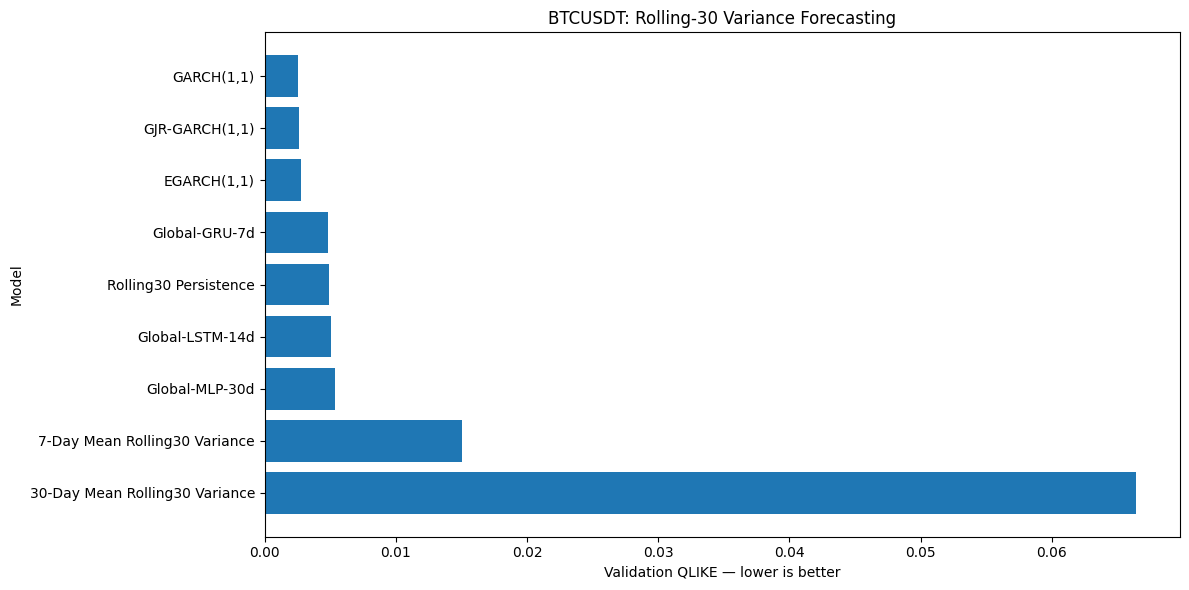

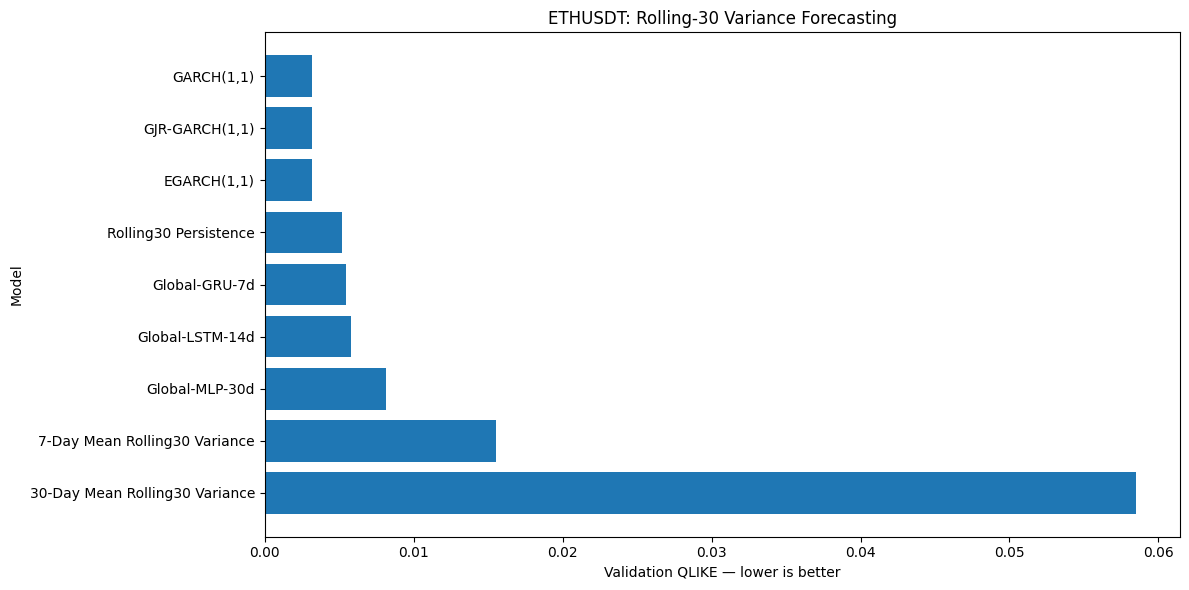

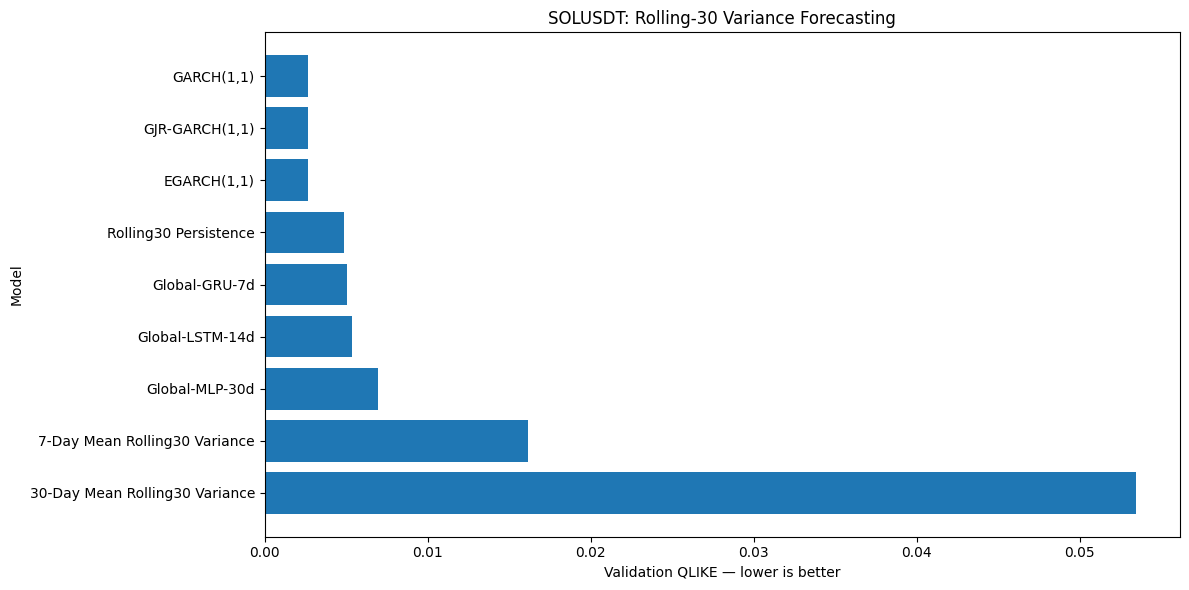

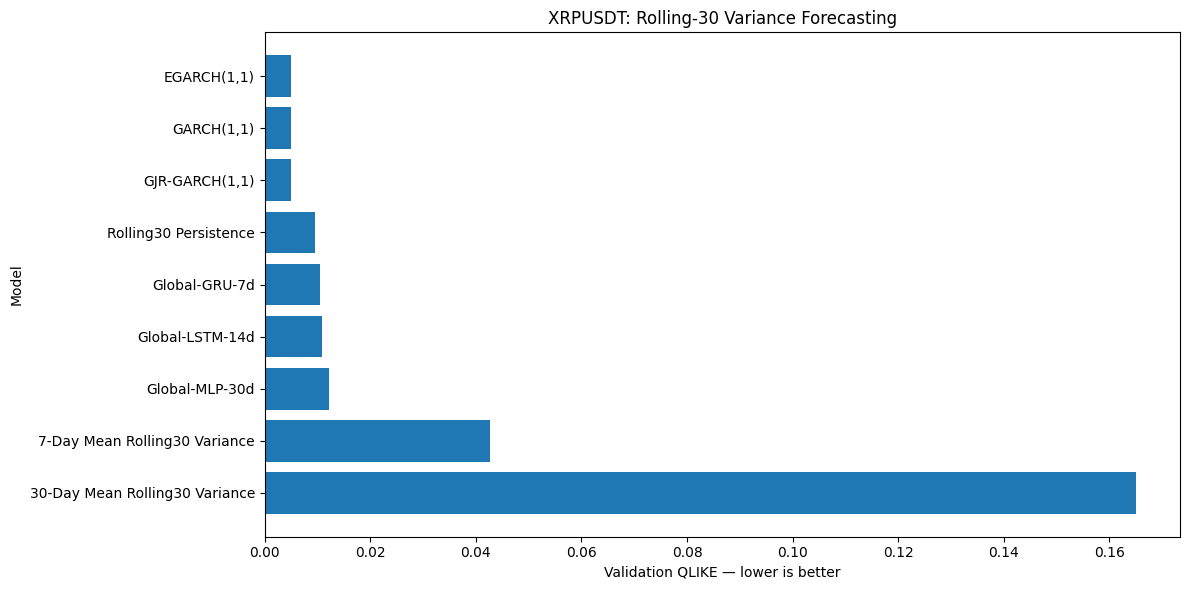

In [16]:
for asset in ASSETS:

    plot_df = (
        final_cross_asset_df.loc[
            final_cross_asset_df[
                "asset"
            ].eq(asset)
        ]
        .sort_values(
            "qlike",
            ascending=True,
        )
        .copy()
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.barh(
        plot_df[
            "model"
        ],
        plot_df[
            "qlike"
        ],
    )

    plt.xlabel(
        "Validation QLIKE — lower is better"
    )

    plt.ylabel(
        "Model"
    )

    plt.title(
        f"{asset}: Rolling-30 "
        "Variance Forecasting"
    )

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

## 17. Final QC

In [17]:
# Global models: 365 validation observations per asset/model.
global_counts = (
    global_dl_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .size()
)

assert (
    global_counts
    == 365
).all()

# All reported QLIKE values should be non-negative.
assert (
    final_cross_asset_df[
        "qlike"
    ]
    >= -1e-12
).all()

assert (
    btc_metrics_df[
        "qlike"
    ]
    >= -1e-12
).all()

# All predicted variance values must be positive.
assert (
    global_dl_predictions_df[
        "pred_rolling30_variance"
    ]
    > 0
).all()

assert (
    btc_predictions_df[
        "pred_rolling30_variance"
    ]
    > 0
).all()

# Validation date coverage is canonical.
assert (
    global_dl_predictions_df[
        "target_date"
    ].min()
    == VALIDATION_START
)

assert (
    global_dl_predictions_df[
        "target_date"
    ].max()
    == VALIDATION_END
)

assert (
    btc_predictions_df[
        "target_date"
    ].min()
    == VALIDATION_START
)

assert (
    btc_predictions_df[
        "target_date"
    ].max()
    == VALIDATION_END
)

print(
    "All rolling-30 DL robustness "
    "QC checks passed."
)

All rolling-30 DL robustness QC checks passed.


## Interpretation

The primary robustness outputs are:

```text
results/
└── rolling30_historical_variance/
    ├── ARCH/
    │   └── rolling30_arch_and_baseline_validation_metrics.csv
    ├── BTCUSDT/
    │   └── rolling30_btc_all_models_validation_comparison.csv
    └── GLOBAL_4_ASSETS/
        ├── rolling30_global_dl_validation_metrics.csv
        ├── rolling30_global_dl_validation_predictions.parquet
        ├── rolling30_final_validation_comparison_by_asset.csv
        └── rolling30_best_validation_model_by_asset.csv
```

Use `rolling30_final_validation_comparison_by_asset.csv` as the main four-asset robustness table.

The final comparison should be interpreted separately from the primary squared-daily-return target:

- primary experiment: forecast next-day daily variance proxy \(r_{t+1}^2\);
- robustness experiment: forecast next-day updated 30-day rolling historical variance.

QLIKE remains the primary ranking metric within each target definition.